In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [17]:
class Adams_methods:
    def __init__(self,y0,h,ti,tf,f,real_f):
        self.y0 = y0
        self.h = h
        self.ti = ti
        self.tf = tf
        self.f = f
        self.real_f = real_f

    def euler(self):
        N = int(np.ceil((self.tf - self.ti) / self.h))
        y = np.zeros(N + 1)
        t = np.zeros(N + 1)
        y[0] = self.y0
        t[0] = self.ti
        for i in range(N):
            y[i + 1] = y[i] + self.h*self.f(t[i],y[i])
            t[i + 1] = t[i] + self.h

        return t,y
    
    def runge_kutta_4(self):
        N = int(np.ceil((self.tf - self.ti) / self.h))
        t = np.zeros(N + 1)
        y = np.zeros(N + 1)
        y[0] = self.y0
        t[0] = self.ti
        for i in range(N):
            k1 = self.h*self.f(t[i],y[i])
            k2 = self.h*self.f(t[i] + self.h/2, y[i] + (1/2)*k1)
            k3 = self.h*self.f(t[i] + self.h/2, y[i] + (1/2)*k2)
            t[i + 1] = t[i] + self.h
            k4 = self.h*self.f(t[i + 1],y[i] + k3)
            y[i + 1] = y[i] + (1/6)*(k1 + 2*k2 + 2*k3 + k4)
        return t,y
    
    def adams2(self):
        N = int(np.ceil((self.tf-self.ti)/self.h))
        t = np.zeros(N + 1)
        y = np.zeros(N + 1)
        y[0],y[1]= self.y0,self.real_f(self.ti + self.h)
        t[1] = t[0] + self.h
        for i in range(1,N):
            t[i + 1] = t[i] + self.h
            y[i + 1] = y[i] + (self.h/2)*(3*self.f(t[i],y[i]) - self.f(t[i - 1], y[i - 1]))

        return t,y

    def adams3(self):
        N = int(np.ceil((self.tf-self.ti)/self.h))
        t = np.zeros(N + 1)
        y = np.zeros(N + 1)
        y[0],y[1],y[2]= self.y0,self.real_f(self.ti + self.h),self.real_f(self.ti + 2*self.h)
        t[1],t[2] = t[0] + self.h, t[0] + 2*self.h
        for i in range(2,N):
            t[i + 1] = t[i] + self.h
            y[i + 1] = y[i] + (self.h/12)*(23*self.f(t[i],y[i]) - 16*self.f(t[i - 1], y[i - 1]) + 5*self.f(t[i - 2],y[i - 2]))

        return t,y

    def adams4(self):
        N = int(np.ceil((self.tf-self.ti)/self.h))
        t = np.zeros(N + 1)
        y = np.zeros(N + 1)
        y[0],y[1],y[2],y[3]= self.y0,self.real_f(self.ti + self.h),self.real_f(self.ti + 2*self.h), self.real_f(self.ti + 3*self.h)
        t[1],t[2],t[3] = t[0] + self.h, t[0] + 2*self.h, t[0] + 3*self.h
        for i in range(3,N):
            t[i + 1] = t[i] + self.h
            y[i + 1] = y[i] + (self.h/24)*(55*self.f(t[i],y[i]) - 59*self.f(t[i - 1], y[i - 1]) + 37*self.f(t[i - 2],y[i - 2]) - 9*self.f(t[i - 3],y[i-3]))

        return t,y 
    
    def adams2_RK(self):
        N = int(np.ceil((self.tf-self.ti)/self.h))
        y = np.zeros(N + 1)
        t,r = self.runge_kutta_4()
        y[0],y[1]= self.y0,r[1]
        for i in range(1,N):
            y[i + 1] = y[i] + (self.h/2)*(3*self.f(t[i],y[i]) - self.f(t[i - 1], y[i - 1]))

        return t,y

    def adams3_RK(self):
        N = int(np.ceil((self.tf-self.ti)/self.h))
        y = np.zeros(N + 1)
        t,r = self.runge_kutta_4()
        y[0],y[1],y[2]= self.y0,r[1],r[2]
        for i in range(2,N):
            t[i + 1] = t[i] + self.h
            y[i + 1] = y[i] + (self.h/12)*(23*self.f(t[i],y[i]) - 16*self.f(t[i - 1], y[i - 1]) + 5*self.f(t[i - 2],y[i - 2]))

        return t,y

    def adams4_RK(self):
        N = int(np.ceil((self.tf-self.ti)/self.h))
        y = np.zeros(N + 1)
        t,r = self.runge_kutta_4()
        y[0],y[1],y[2],y[3]= self.y0, r[1],r[2],r[3]
        for i in range(3,N):
            y[i + 1] = y[i] + (self.h/24)*(55*self.f(t[i],y[i]) - 59*self.f(t[i - 1], y[i - 1]) + 37*self.f(t[i - 2],y[i - 2]) - 9*self.f(t[i - 3],y[i-3]))
        
        return t,y
    
    def abs_error(self):
        t,y_2 = self.adams2()
        t,y_3 = self.adams3()
        t,y_4 = self.adams4()
        y_real = self.real_f(t)

        t,y_2_rk = self.adams2_RK()
        t,y_3_rk = self.adams3_RK()
        t,y_4_rk = self.adams4_RK()

        erro_ab2 = abs(y_real - y_2)
        erro_ab3 = abs(y_real - y_3)
        erro_ab4 = abs(y_real - y_4)

        erro_ab2_rk = abs(y_real - y_2_rk)
        erro_ab3_rk = abs(y_real - y_3_rk)
        erro_ab4_rk = abs(y_real - y_4_rk)



        erro = np.column_stack(([erro_ab2,erro_ab2_rk,erro_ab3,erro_ab3_rk,erro_ab4,erro_ab4_rk]))

        erro_df = pd.DataFrame(erro, columns = ["Erro_AB2","Erro_AB2 RK", "Erro_AB3","Erro_AB3 RK", "Erro_AB4", "Erro_AB4 RK"],
                            index = np.round(t,2))
        
        return erro_df

In [18]:
def f(t,y):
    return t*np.exp(t*3) - 2*y

def real_f(t):
    return (1/5)*t*np.exp(3*t) - (1/25)*np.exp(3*t) + (1/25)*np.exp(-2*t)

In [19]:
methods = Adams_methods(0,0.2,0,1,f,real_f)

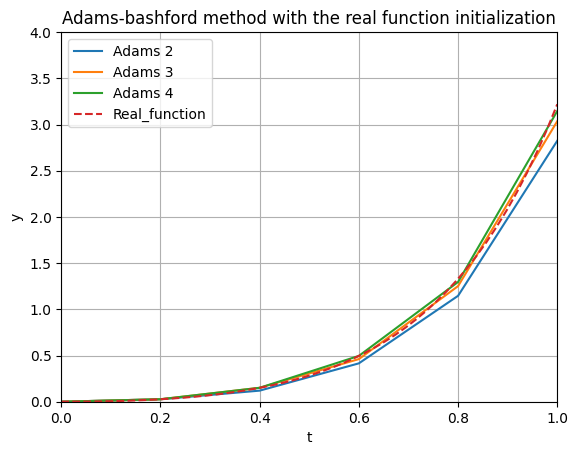

In [20]:
t_2,y_2 = methods.adams2()
t_3,y_3 = methods.adams3()
t_4,y_4 = methods.adams4()
t_real = np.linspace(0,1)
plt.plot(t_2,y_2, label = "Adams 2")
plt.plot(t_3,y_3, label = "Adams 3")
plt.plot(t_4,y_4, label = "Adams 4")
plt.plot(t_real,real_f(t_real), linestyle = '--',label = "Real_function")
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.axis([0,1,0,4])
plt.title("Adams-bashford method with the real function initialization")
plt.legend()
plt.grid()
plt.savefig("Adams-bashford real init")
plt.show()

Exercício 2

In [21]:
def f(t,y):
    return -(y + 1)*(y + 3)

def real_f(t):
    return -3 + 2/(1 + np.exp(-2*t))

In [22]:
methods = Adams_methods(-2,0.4,0,2,f,real_f)

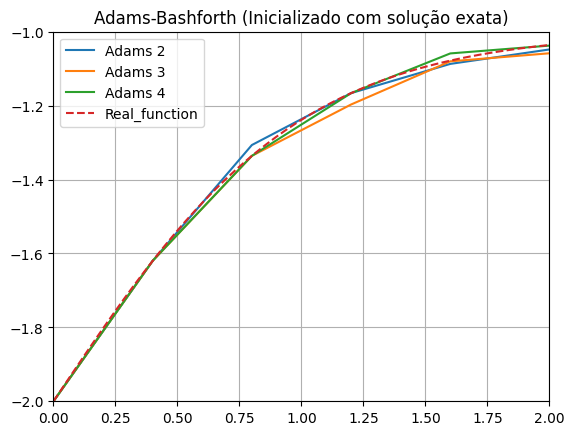

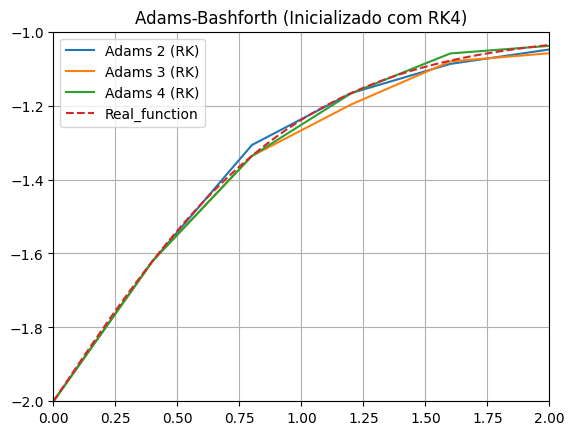

In [23]:
t_4,y_4 = methods.adams4()
t_3,y_3 = methods.adams3()
t_2,y_2 = methods.adams2()

t_2_rk,y_2_rk = methods.adams2_RK()
t_3_rk,y_3_rk = methods.adams3_RK()
t_4_rk,y_4_rk = methods.adams4_RK()

t_real = np.linspace(0,2)
plt.plot(t_2,y_2, label = "Adams 2")
plt.plot(t_3,y_3, label = "Adams 3")
plt.plot(t_4,y_4, label = "Adams 4")
plt.title("Adams-Bashforth (Inicializado com solução exata)")
plt.plot(t_real,real_f(t_real), linestyle = '--',label = "Real_function")
plt.legend()
plt.axis([0,2,-2,-1])
plt.grid()
plt.savefig("Adams-bashforth with real func init")
plt.show()

plt.plot(t_2_rk,y_2_rk, label = "Adams 2 (RK)")
plt.plot(t_3_rk,y_3_rk, label = "Adams 3 (RK)")
plt.plot(t_4_rk,y_4_rk, label = "Adams 4 (RK)")
plt.title("Adams-Bashforth (Inicializado com RK4)")
plt.plot(t_real,real_f(t_real), linestyle = '--',label = "Real_function")
plt.axis([0,2,-2,-1])
plt.legend()
plt.grid()
plt.savefig("Adams-bashforth with RK")
plt.show()

In [24]:
y_real = real_f(t_2)

erro_ab2 = abs(y_real - y_2)
erro_ab3 = abs(y_real - y_3)
erro_ab4 = abs(y_real - y_4)

erro_ab2_rk = abs(y_real - y_2_rk)
erro_ab3_rk = abs(y_real - y_3_rk)
erro_ab4_rk = abs(y_real - y_4_rk)



erro = np.vstack(([erro_ab2,erro_ab2_rk,erro_ab3,erro_ab3_rk,erro_ab4,erro_ab4_rk]))
erro = erro.transpose()

erro_df = pd.DataFrame(erro, columns = ["Erro_AB2","Erro_AB2 RK", "Erro_AB3","Erro_AB3 RK", "Erro_AB4", "Erro_AB4 RK"],
                       index = ["0.00","0.40","0.80","1.20","1.60","2.00"])

In [25]:
error = methods.abs_error()

In [26]:
error

,Erro_AB2,Erro_AB2 RK,Erro_AB3,Erro_AB3 RK,Erro_AB4,Erro_AB4 RK
0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.4,0.000000,0.000092,0.000000,0.000092,0.000000,0.000092
0.8,0.029295,0.029245,0.000000,0.000324,0.000000,0.000324
1.2,0.000124,0.000102,0.030683,0.030714,0.000000,0.000542
1.6,0.008860,0.008874,0.001905,0.002115,0.019494,0.019401
2.0,0.012113,0.012119,0.022454,0.022323,0.001701,0.002268


Exercício 3

In [27]:
def f(t,y):
    return 1 + y/t

def real_f(t):
    return t*np.log(t) + 2*t

In [28]:
def adams_m2(y0,h,ti,tf,f,real_f):
    Methods = Adams_methods(y0,h,ti,tf,f,real_f)
    N = int(np.ceil((tf-ti)/h))
    y = np.zeros(N + 1)
    t,r = Methods.euler()
    y[0],y[1]= y0,r[1]
    for i in range(1,N):
        y[i + 1] = (y[i] + (5*h/12) + ((h/12)*(8*f(t[i],y[i]) - f(t[i-1],y[i - 1]))))/(1-(5/12)*h/(t[i] + h))
    return t,y

def adams_m3(y0,h,ti,tf,f,real_f):
    Methods = Adams_methods(y0,h,ti,tf,f,real_f)
    N = int(np.ceil((tf-ti)/h))
    y = np.zeros(N + 1)
    t,r = Methods.euler()
    y[0],y[1],y[2]= y0,r[1],r[2]
    for i in range(1,N):
        y[i + 1] = (y[i] + 9*h/24 + (h/24)*(19*f(t[i],y[i]) - 5*f(t[i - 1],y[i-1]) + f(t[i - 2],y[i - 2]))) / (1 - (9*h/24)*1/(t[i] + h))
    return t,y

In [29]:
methods = Adams_methods(2,0.5,1,5,f,real_f)
t,y_adams_2 = adams_m2(2,0.5,1,5,f,real_f)
t,y_adams_3 = adams_m3(2,0.5,1,5,f,real_f)
t,y_euler = methods.euler()

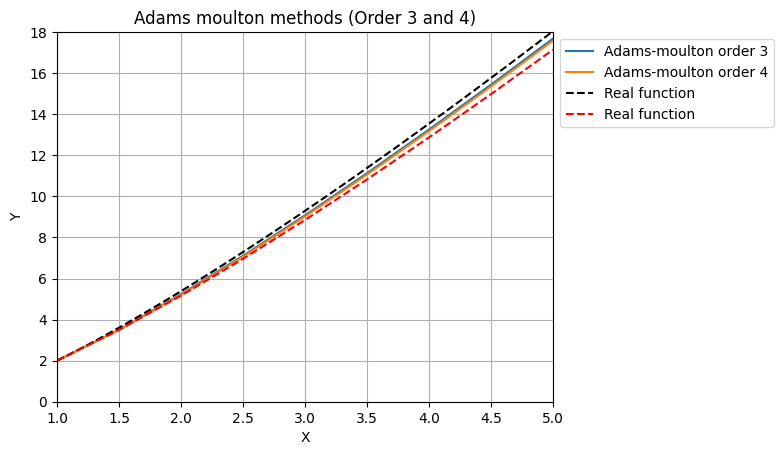

In [31]:
plt.plot(t,y_adams_2, label = "Adams-moulton order 3")
plt.plot(t,y_adams_3, label = "Adams-moulton order 4")
plt.plot(np.linspace(1,5),real_f(np.linspace(1,5)), label = "Real function", linestyle = '--', color = 'black')
plt.plot(t,y_euler, label = "Real function", color = 'red', linestyle = '--')
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.title("Adams moulton methods (Order 3 and 4)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis([1,5,0,18])
plt.grid()
plt.savefig("Comparison with explicit adams-bashforth and adams-moulton")
plt.show()

Exercício 4

In [32]:
def f(t,y):
    return 1 + y/t + (y/t)**2

def real_f(t):
    return t*np.tan(np.log(t))

In [33]:
def preditor(y0,h,ti,tf,f,real_f):
    Methods = Adams_methods(y0,h,ti,tf,f,real_f)
    t,y_pred = Methods.adams3_RK()
    return t,y_pred

def corretor(y0,h,ti,tf,f,real_f):
    Methods = Adams_methods(y0,h,ti,tf,f,real_f)
    N = int(np.ceil((tf - ti) / h))
    t,y_pred = preditor(y0,h,ti,tf,f,real_f)
    t,r = Methods.runge_kutta_4();
    y_corr = np.zeros(N + 1)
    y_corr[0],y_corr[1] = y0,r[1]
    for i in range(1,N):
        y_corr[i + 1] = y_corr[i] + (h/12)*(5*f(t[i + 1],y_pred[i + 1]) + 8*f(t[i],y_corr[i]) - f(t[i - 1],y_corr[i - 1]))
    return t,y_corr

In [34]:
Methods = Adams_methods(0,0.3,1,4,f,real_f)
t,y_pred_cor = corretor(0,0.3,1,4,f,real_f)
t,y_bashforth = Methods.adams3_RK()

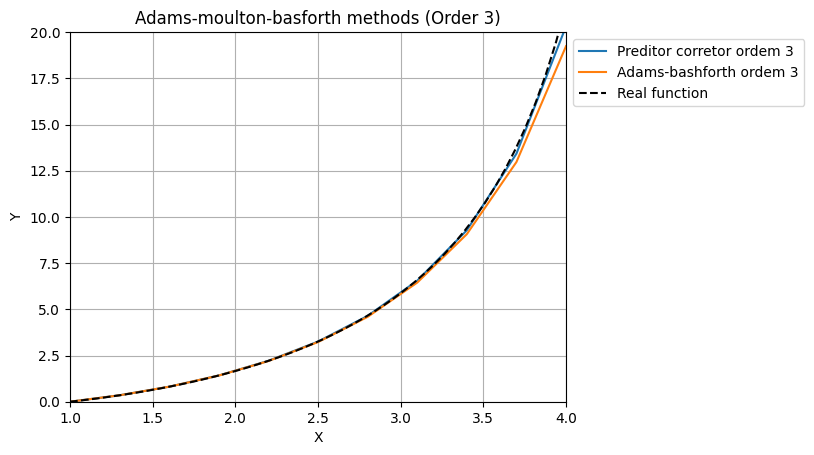

In [37]:
plt.plot(t,y_pred_cor, label = "Preditor corretor ordem 3")
plt.plot(t,y_bashforth, label = "Adams-bashforth ordem 3")
plt.title("Adams-moulton-basforth methods (Order 3)")
plt.plot(np.linspace(1,4),real_f(np.linspace(1,4)), label = "Real function", linestyle = '--', color = 'black')
plt.xlabel("X")
plt.ylabel("Y")
plt.axis([1,4,0,20])
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.grid()
plt.savefig("Comparison with adams-bashforth (order 3) with predictor-corretor method (order 3)")
plt.show()